# Explainability + Unsupervised Learning - Phase 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
# Load Data

train_df = pd.read_csv("data/processed/train_2010_2022.csv")
test_df = pd.read_csv("data/processed/test_2023_2025.csv")

eda_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("EDA Dataset:", eda_df.shape)

EDA Dataset: (154, 17)


In [3]:
# Define Features and Target

numeric_features = [
    "draft_pick_overall",
    "age_on_draft_day",
    "height_inches",
    "weight_lbs",
    "college_games_played",
    "career_yards",
    "career_touchdowns"
]

categorical_features = [
    "position"
]

target_regression = "rookie_total_ppr_points"
target_classification = "fantasy_relevant_binary"

## Part A - Feature Importance

In [4]:
# Feature Engineering Pipeline - Build Preprocessor for Random Forest

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [5]:
# Prepare Train/Test Data

X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]

y_train_reg = train_df[target_regression]
y_test_reg = test_df[target_regression]

y_train_class = train_df[target_classification]
y_test_class = test_df[target_classification]

In [6]:
# Fit Random Forest Regressor

rf_reg_explain = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=4,
        random_state=88
    ))
])

rf_reg_explain.fit(X_train, y_train_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [7]:
# Extract Feature Names

feature_names_num = numeric_features

onehot = rf_reg_explain.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

feature_names_cat = onehot.get_feature_names_out(categorical_features)

feature_names = list(feature_names_num) + list(feature_names_cat)

feature_names

['draft_pick_overall',
 'age_on_draft_day',
 'height_inches',
 'weight_lbs',
 'college_games_played',
 'career_yards',
 'career_touchdowns',
 'position_QB',
 'position_RB',
 'position_TE',
 'position_WR']

In [ ]:
# Regression Feature Importance

rf_reg_importances = rf_reg_explain.named_steps["model"].feature_importances_

reg_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_reg_importances
}).sort_values("importance", ascending=False)

reg_importance_df

,feature,importance
0,draft_pick_overall,0.433070
3,weight_lbs,0.122174
4,college_games_played,0.118882
5,career_yards,0.097678
6,career_touchdowns,0.095682
2,height_inches,0.076860
1,age_on_draft_day,0.033478
8,position_RB,0.013587
10,position_WR,0.004944
9,position_TE,0.002636


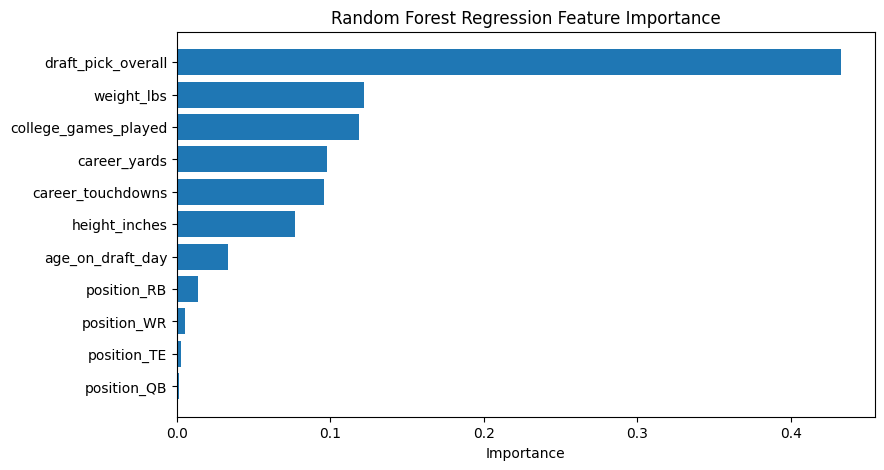

In [9]:
# Plot Regression Feature Importance

plt.figure(figsize=(9, 5))
plt.barh(
    reg_importance_df["feature"],
    reg_importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Regression Feature Importance")
plt.show()

In [10]:
# Fit Random Forest Classifier

rf_clf_explain = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        random_state=88,
        class_weight="balanced"
    ))
])

rf_clf_explain.fit(X_train, y_train_class)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
# Classification Feature Importance

rf_clf_importances = rf_clf_explain.named_steps["model"].feature_importances_

clf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_clf_importances
}).sort_values("importance", ascending=False)

clf_importance_df

,feature,importance
5,career_yards,0.202032
6,career_touchdowns,0.175824
3,weight_lbs,0.130124
0,draft_pick_overall,0.127335
2,height_inches,0.116330
4,college_games_played,0.092953
7,position_QB,0.081204
1,age_on_draft_day,0.036016
8,position_RB,0.025539
10,position_WR,0.010170


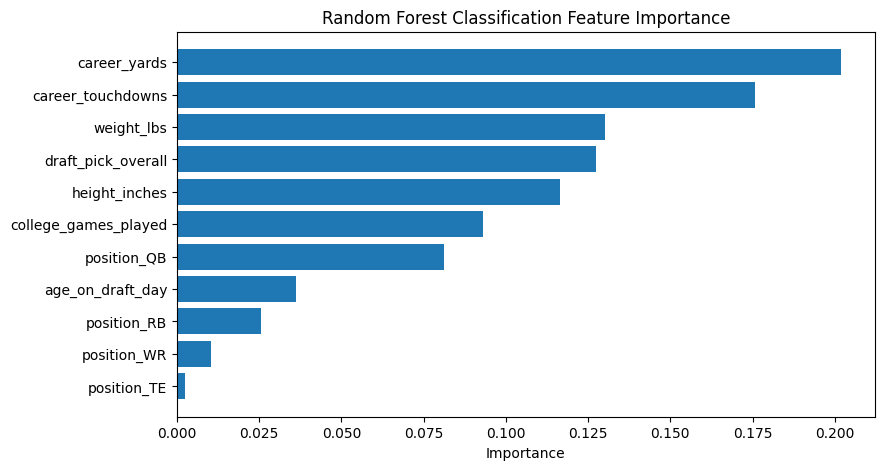

In [12]:
# Plot Classification Feature Importance

plt.figure(figsize=(9, 5))
plt.barh(
    clf_importance_df["feature"],
    clf_importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Classification Feature Importance")
plt.show()

## Part B - PCA + Clustering

In [13]:
# Create Unsupervised Dataset

unsup_features = numeric_features + categorical_features

unsup_df = eda_df[unsup_features].copy()

unsup_df.head()

,draft_pick_overall,age_on_draft_day,height_inches,weight_lbs,college_games_played,career_yards,career_touchdowns,position
0,1,22,76,224,31,8403,88,QB
1,9,23,71,194,52,3547,32,RB
2,12,22,72,220,31,3280,39,RB
3,21,22,77,260,41,1629,26,TE
4,22,22,75,225,39,2339,15,WR


In [14]:
# Preprocess for PCA and Clustering

numeric_pipeline_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_encoded = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

unsup_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_scaled, numeric_features),
        ("cat", categorical_pipeline_encoded, categorical_features)
    ]
)

X_unsup = unsup_preprocessor.fit_transform(unsup_df)

print("Unsupervised Matrix Shape:", X_unsup.shape)

Unsupervised Matrix Shape: (154, 11)


In [15]:
# Run PCA

pca = PCA(n_components=2, random_state=88)

X_pca = pca.fit_transform(X_unsup)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.35804741 0.22106123]
Total variance explained:
0.5791086390541387


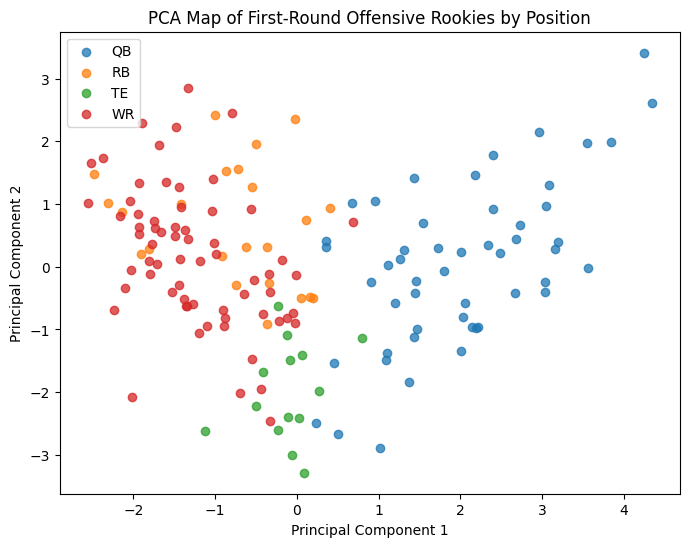

In [16]:
# PCA Visualization by Position

pca_df = eda_df[[
    "player_name",
    "season",
    "position",
    "rookie_total_ppr_points",
    "fantasy_relevant_binary"
]].copy()

pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))

for pos in pca_df["position"].unique():
    subset = pca_df[pca_df["position"] == pos]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=pos,
        alpha=0.75
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Map of First-Round Offensive Rookies by Position")
plt.legend()
plt.show()

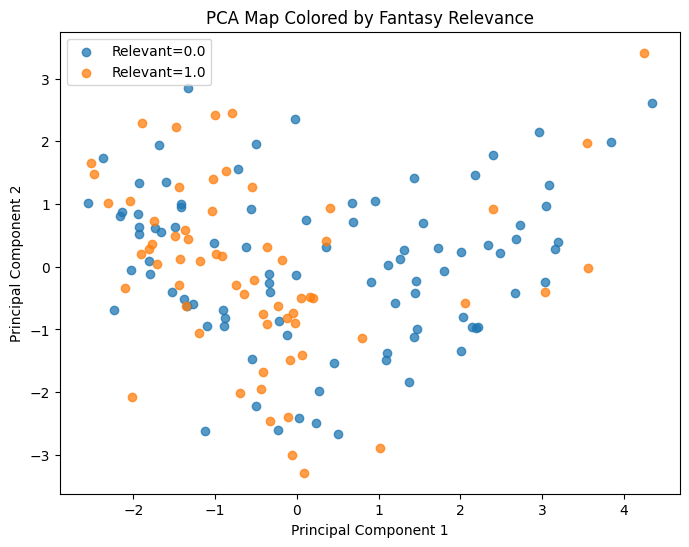

In [17]:
# PCA Visualization by Fantasy Relevance

plt.figure(figsize=(8, 6))

for label in sorted(pca_df["fantasy_relevant_binary"].unique()):
    subset = pca_df[pca_df["fantasy_relevant_binary"] == label]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Relevant={label}",
        alpha=0.75
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Map Colored by Fantasy Relevance")
plt.legend()
plt.show()

In [18]:
# K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=88,
    n_init=10
)

clusters = kmeans.fit_predict(X_unsup)

pca_df["cluster"] = clusters

pca_df.head()

,player_name,season,position,rookie_total_ppr_points,fantasy_relevant_binary,PC1,PC2,cluster
0,Sam Bradford,2010,QB,245.7,0.0,2.667097,-0.425021,1
1,C.J. Spiller,2010,RB,95.2,0.0,-0.495943,1.957109,0
2,Ryan Mathews,2010,RB,158.3,0.0,-0.344573,-0.262771,2
3,Jermaine Gresham,2010,TE,112.1,0.0,0.266069,-1.974057,2
4,Demaryius Thomas,2010,WR,52.3,0.0,-0.899464,-0.694415,2


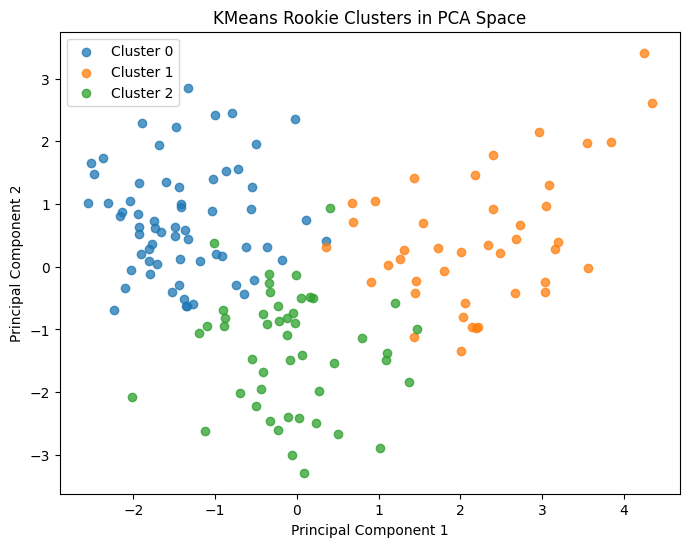

In [19]:
# Plot Clusters in PCA Space

plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.75
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Rookie Clusters in PCA Space")
plt.legend()
plt.show()

In [20]:
# Cluster Summary

cluster_summary = pca_df.groupby("cluster").agg(
    player_count=("player_name", "count"),
    avg_ppr_points=("rookie_total_ppr_points", "mean"),
    fantasy_relevance_rate=("fantasy_relevant_binary", "mean")
).reset_index()

cluster_summary

,cluster,player_count,avg_ppr_points,fantasy_relevance_rate
0,0,64,168.526563,0.531250
1,1,42,191.252381,0.142857
2,2,48,165.425000,0.479167


In [21]:
# Position Breakdown by Cluster

pd.crosstab(
    pca_df["cluster"],
    pca_df["position"],
    normalize="index"
).round(2)


position,QB,RB,TE,WR
cluster,,,,
0,0.02,0.27,0.00,0.72
1,0.98,0.00,0.00,0.02
2,0.19,0.12,0.29,0.40


In [22]:
# Example Players by Cluster

for cluster in sorted(pca_df["cluster"].unique()):
    print(f"\nCluster {cluster}")
    display(
        pca_df[pca_df["cluster"] == cluster][
            ["player_name", "season", "position", "rookie_total_ppr_points", "fantasy_relevant_binary"]
        ].head(10)
    )


Cluster 0


,player_name,season,position,rookie_total_ppr_points,fantasy_relevant_binary
1,C.J. Spiller,2010,RB,95.2,0.0
7,Jahvid Best,2010,RB,218.8,1.0
15,Mark Ingram,2011,RB,131.0,0.0
18,Trent Richardson,2012,RB,267.9,1.0
19,Justin Blackmon,2012,WR,192.5,1.0
22,Kendall Wright,2012,WR,189.6,1.0
24,A.J. Jenkins,2012,WR,0.0,0.0
25,Doug Martin,2012,RB,319.6,1.0
26,David Wilson,2012,RB,74.4,0.0
27,Tavon Austin,2013,WR,151.8,0.0



Cluster 1


,player_name,season,position,rookie_total_ppr_points,fantasy_relevant_binary
0,Sam Bradford,2010,QB,245.7,0.0
6,Tim Tebow,2010,QB,61.7,0.0
11,Jake Locker,2011,QB,18.7,0.0
13,Christian Ponder,2011,QB,134.0,0.0
16,Andrew Luck,2012,QB,339.7,1.0
17,Robert Griffin-III,2012,QB,357.1,1.0
20,Ryan Tannehill,2012,QB,250.6,0.0
23,Brandon Weeden,2012,QB,219.8,0.0
28,EJ Manuel,2013,QB,171.9,0.0
32,Blake Bortles,2014,QB,200.9,0.0



Cluster 2


,player_name,season,position,rookie_total_ppr_points,fantasy_relevant_binary
2,Ryan Mathews,2010,RB,158.3,0.0
3,Jermaine Gresham,2010,TE,112.1,0.0
4,Demaryius Thomas,2010,WR,52.3,0.0
5,Dez Bryant,2010,WR,187.1,1.0
8,Cam Newton,2011,QB,385.0,1.0
9,A.J. Green,2011,WR,247.7,1.0
10,Julio Jones,2011,WR,180.9,1.0
12,Blaine Gabbert,2011,QB,135.3,0.0
14,Jonathan Baldwin,2011,WR,30.1,0.0
21,Michael Floyd,2012,WR,65.2,0.0


In [23]:
# Save Phase 7 Outputs

reg_importance_df.to_csv("data/processed/regression_feature_importance.csv", index=False)
clf_importance_df.to_csv("data/processed/classification_feature_importance.csv", index=False)
pca_df.to_csv("data/processed/pca_cluster_results.csv", index=False)
cluster_summary.to_csv("data/processed/cluster_summary.csv", index=False)

print("Phase 7 outputs saved.")

Phase 7 outputs saved.
